<a href="https://colab.research.google.com/github/suzzette211/AI-For-Science-and-Engineering/blob/main/Assignment_week_3_Designing_Your_Machine_Learning_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem

Manual inspection of concrete structure for cracks is time- consuming and subjective. The project will investigate whether an ML model can automatically identify cracks in concrete images

The model will classify images as cracked or non- cracked.Later, this can be extended to crack segmentation, crack-width/length estimation, severity assessment, and eventually drone-based infrastructure inspection.

In [4]:
#importing kaggle.json file into colab
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"susannzisandambuki","key":"42da7dc065fbcf04a5df497fe60a4131"}'}

In [7]:
# Create the directory
!mkdir -p ~/.kaggle

# Move the API token into it
!cp kaggle.json ~/.kaggle/

# Set correct read/write permissions
!chmod 600 ~/.kaggle/kaggle.json


In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")

print("Path to dataset files:", path)

100%|██████████| 506M/506M [00:05<00:00, 97.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1


Total images found in dataset: 56092


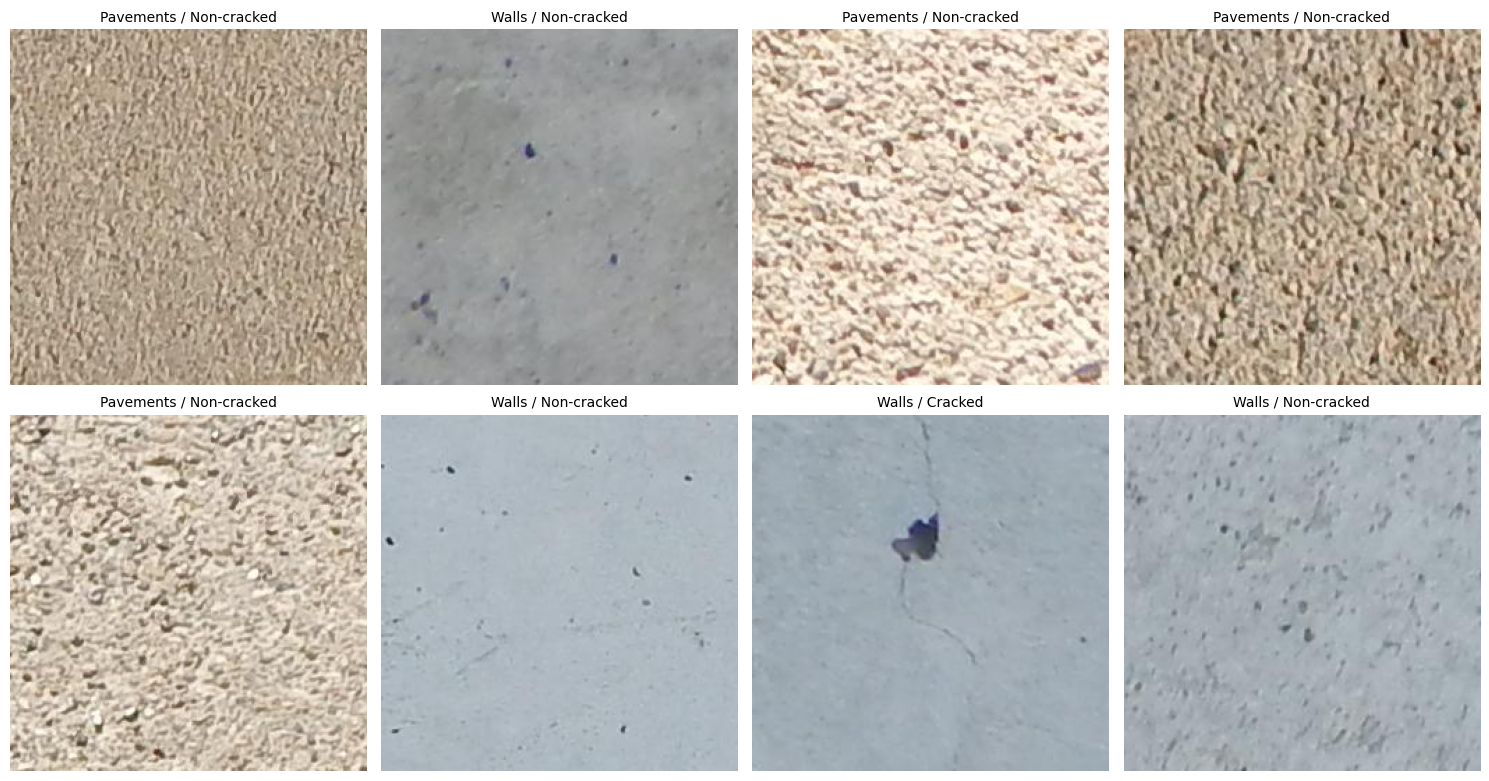

In [9]:
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Use glob to recursively find all .jpg images inside your kagglehub 'path'
# This automatically handles nested folders like 'W', 'P', or 'D' and 'Cracked'/'Non-cracked'
image_paths = glob.glob(os.path.join(path, "**/*.jpg"), recursive=True)

print(f"Total images found in dataset: {len(image_paths)}")

# 2. Pick 8 random images to display
sample_images = random.sample(image_paths, min(8, len(image_paths)))

# 3. Create a 2x4 grid layout for plotting
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel() # Flatten grid array into 1D for easy indexing

for i, img_path in enumerate(sample_images):
    # Open the image using PIL
    img = Image.open(img_path)
    axes[i].imshow(img)

    # Extract subfolder names to use as a dynamic clean label
    # E.g., showing if it is cracked/non-cracked or wall/pavement
    path_parts = img_path.split(os.sep)
    label = f"{path_parts[-3]} / {path_parts[-2]}" # Custom label mapping folders

    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off') # Hide pixel grid coordinate lines

plt.tight_layout()
plt.show()


**Identify the potential inputs (features) and output (target) for your project.**



*  **Inputs/features :** image/ pixel information
*  **Target :** crack vs no_crack
segmentation, for crack get the length, width, orientation and area. In future do automated infrastructure condition assessment.





**ML workflow**

Image → preprocessing → train/validation → CNN → prediction → evaluation



1.  Image (Data collection)

I am using the SDNET2018 concrete crack dataset which I pulled directly into my Google Colab notebook using kagglehub. Right now, my input data consists of thousands of raw digital JPGs. My main goal in this phase is to explore the folder structure so I know exactly where the 'Cracked' and 'Non-Cracked' classes are stored across the structural categories (walls, pavements, and decks).

2.   Preprocessing

In this step, I write code to standardize them. I am resizing all the images to a uniform 224 × 224 pixels so the model gets consistent inputs. I am also normalizing the pixel values from their original range of 0–255 down to 0–1. This prevents mathematical gradients from exploding and helps my model converge much faster during training.

3. Training

To make sure my model is actually learning features rather than just memorizing my dataset, I have to simulate a testing environment. I am splitting my preprocessed images into an 80/20 train/validation split. I will use the 80% training set to let the network adjust its weights and learn what a concrete crack looks like. I am locking away the remaining 20% validation set to act as a hidden exam. The model won't see these images during training; they will only be used to evaluate how well it generalizes to concrete surfaces it has never encountered before.

4. CNN (model Architecture)

I am implementing a Convolutional Neural Network (CNN). I chose a CNN because its layered architecture is designed specifically for spatial data like images. The early convolutional layers will automatically extract low-level features like edges, shadows, and color gradients. As the data flows deeper into the network, the max-pooling and dense layers will combine those edges into high-level features—allowing the network to distinguish a jagged structural crack from a benign shadow or surface texture.

5. Prediction

Once my CNN model is compiled and trained, I put it to work. When I feed a completely new, unlabeled image of a concrete wall into the network, the model processes the pixels through its learned filters. It outputs a probability score between 0 and 1. If the score is higher than 0.5, the model flags it and prints the final prediction to my screen: 'Cracked' (or 'Non-Cracked' if the score is lower).

6. Evaluation

The final step of my project is documenting how well my model actually performed. I will run my validation dataset through the trained model and generate a confusion matrix and a classification report. I am looking closely at metrics like Accuracy (overall correctness) and Recall (ensuring my model didn't accidentally skip a dangerous crack and label it safe). This evaluation data is what I will put into my final project report and graphs to prove to  that the network successfully learned the task.
